## Ridge Regression

Ridge Regression is a type of **regularized linear regression** used to reduce overfitting in machine learning models.

It modifies the ordinary linear regression model by adding a **penalty term** to the cost function.

---

## Linear Regression Equation

$$
Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_nX_n
$$

---

## Ridge Regression Cost Function

Ridge Regression adds an **L2 regularization term**:

$$
J(\beta) =
\sum_{i=1}^{m}(y_i - \hat{y}_i)^2
+
\lambda \sum_{j=1}^{n}\beta_j^2
$$

Where:

- $$ (y_i - \hat{y}_i)^2 $$ = Residual Sum of Squares (RSS)
- $$ \lambda $$ = Regularization parameter
- $$ \beta_j^2 $$ = Penalty on large coefficients

---

## Purpose of Ridge Regression

- Reduces model complexity
- Prevents overfitting
- Improves generalization
- Handles multicollinearity problems

---

## Geometric Intuition

In ordinary linear regression, the model tries to minimize only the error.

Ridge Regression minimizes:

$$
\text{Error} + \text{Penalty}
$$

The penalty term forces the coefficient values to stay small.

### Constraint Form

$$
\sum_{j=1}^{n}\beta_j^2 \leq t
$$

This creates a circular constraint region in parameter space.

The optimal solution occurs where:

- Error contours
- Constraint boundary

intersect.

---

## Effect of Regularization Parameter

### When:

$$
\lambda = 0
$$

Ridge Regression becomes ordinary linear regression.

### When:

$$
\lambda \to \infty
$$

Coefficient values shrink toward zero.

---

## Advantages

- Reduces overfitting
- Works well with high-dimensional data
- Stabilizes coefficient estimates
- Useful when features are highly correlated

---

## Disadvantages

- Does not perform feature selection
- All coefficients shrink but never become exactly zero

---

## Key Points

- Ridge Regression uses **L2 Regularization**
- Adds penalty on squared coefficients
- Controls model complexity
- Helps balance bias and variance

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

In [4]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
x = data.data
y = data.target


from sklearn.model_selection import train_test_split

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [15]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
print(lr.coef_)
print(lr.intercept_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
151.34560453985995


In [17]:
y_pred = lr.predict(x_test)

In [18]:
from sklearn.metrics import r2_score,mean_squared_error

print('R2_score',r2_score(y_test,y_pred))
print('RMSE',mean_squared_error(y_test,y_pred))

R2_score 0.45260276297191937
RMSE 2900.193628493482


In [19]:
from sklearn.linear_model import Ridge
R = Ridge(alpha = 100000)  # alpha = lambda value


In [20]:
R.fit(x_train,y_train)

,alpha,100000
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [22]:
print(R.coef_)
print(R.intercept_)

[ 2.50178788e-03  9.31024633e-05  7.85566990e-03  5.92336997e-03
  2.62001500e-03  2.02748670e-03 -4.96365711e-03  5.58198631e-03
  7.25668147e-03  5.18926072e-03]
153.7364971055568


In [24]:
y_pred1=R.predict(x_test)


In [25]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))


R2 score -0.011937773360617188
RMSE 73.2215807212638


In [26]:
#Non-linear Data 
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

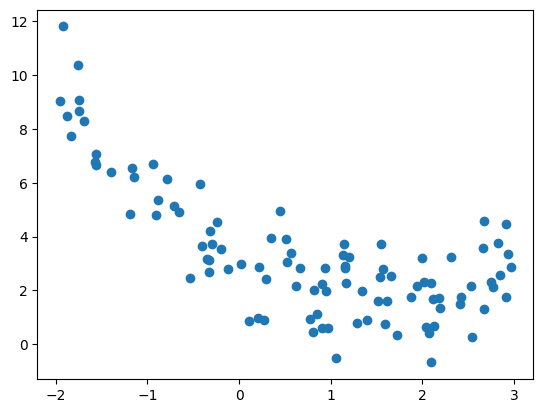

In [27]:
plt.scatter(x1,x2)
plt.show()

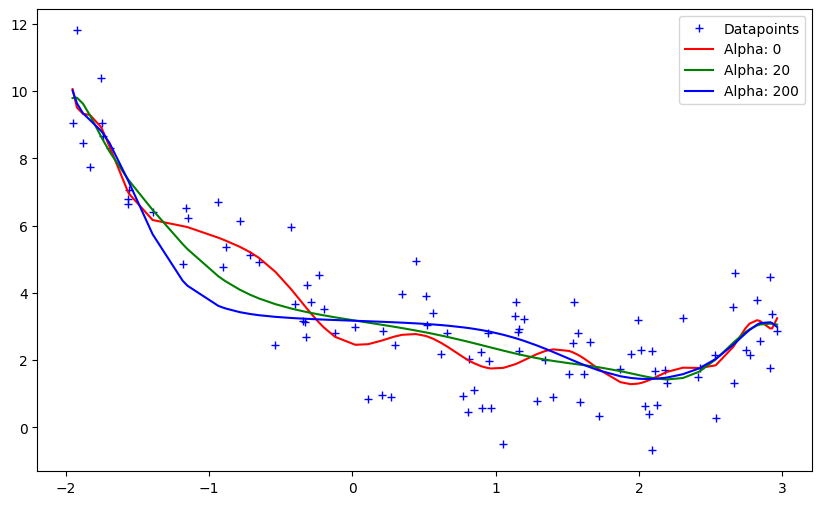

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()